In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import itertools

In [11]:
import seaborn as sns
diamonds = sns.load_dataset('diamonds')
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
print(diamonds.describe())
print(diamonds.info())

              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5.710000      3.530000  
75%        6.540000      4.040000  


In [ ]:
numeric_df = diamonds.select_dtypes(include=['float64', 'int64'])
cols = numeric_df.columns
results = []

# 2, 3 & 4. Compute Pearson and Spearman for each pair, including p-values
for col1, col2 in itertools.combinations(cols, 2):

    p_corr, p_pval = pearsonr(numeric_df[col1], numeric_df[col2])

    s_corr, s_pval = spearmanr(numeric_df[col1], numeric_df[col2])
    
    results.append({
        'Pair': f"{col1} - {col2}",
        'Pearson (r)': p_corr,
        'Pearson p-value': p_pval,
        'Spearman (ρ)': s_corr,
        'Spearman p-value': s_pval
    })

summary_table = pd.DataFrame(results)

summary_table['Abs_Pearson'] = summary_table['Pearson (r)'].abs()
summary_table = summary_table.sort_values(by='Abs_Pearson', ascending=False).drop(columns=['Abs_Pearson'])

display(summary_table)

,Pair,Pearson (r),Pearson p-value,Spearman (ρ),Spearman p-value
3,carat - x,0.975094,0.000000e+00,0.996117,0.000000e+00
18,x - y,0.974701,0.000000e+00,0.997895,0.000000e+00
19,x - z,0.970772,0.000000e+00,0.987355,0.000000e+00
5,carat - z,0.953387,0.000000e+00,0.993183,0.000000e+00
20,y - z,0.952006,0.000000e+00,0.987068,0.000000e+00
4,carat - y,0.951722,0.000000e+00,0.995572,0.000000e+00
2,carat - price,0.921591,0.000000e+00,0.962883,0.000000e+00
15,price - x,0.884435,0.000000e+00,0.963196,0.000000e+00
16,price - y,0.865421,0.000000e+00,0.962719,0.000000e+00
17,price - z,0.861249,0.000000e+00,0.957232,0.000000e+00


Dimensions of diamonds have strong spearman and pearson relationships with each other, price, and carat itself.
Carats also have strong relationship with price


there is noticable difference between pearson and spearman results on the relationship between dimensions and price.


possible cause of that might be, when one dimension changes, other two dimensions tend to change in real life examples, and this cause cubic relation between dimension and price

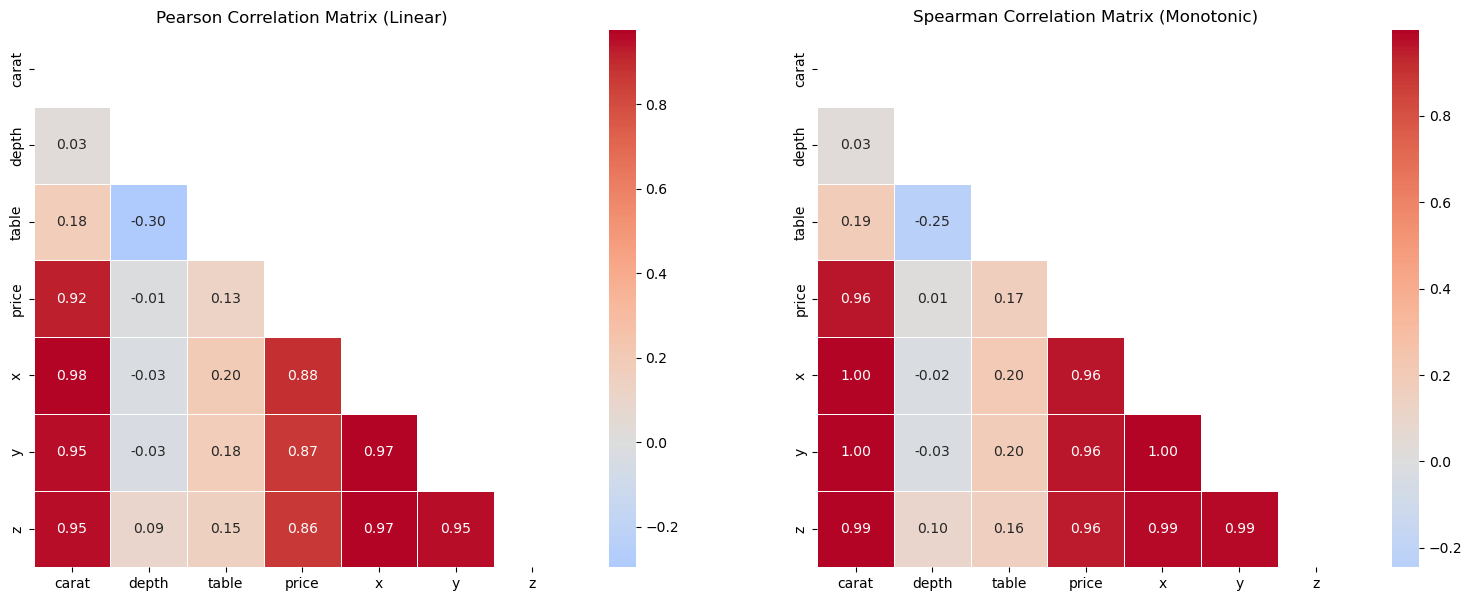

In [ ]:
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', center=0, 
            annot=True, fmt='.2f', square=True, linewidths=.5, ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix (Linear)')

sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, 
            annot=True, fmt='.2f', square=True, linewidths=.5, ax=axes[1])
axes[1].set_title('Spearman Correlation Matrix (Monotonic)')

plt.tight_layout()
plt.show()

as I stated in previous task's markdown which is direct result of task one's output, most noticeable unagreement between results
of spearman and pearson are between dimensions and price, which I stated possible cause earlier

Nearly all other outputs, exept I stated earlier, results of spearman and pearson mostly agrees with each other 

Generating plots for Dimensions vs Price...


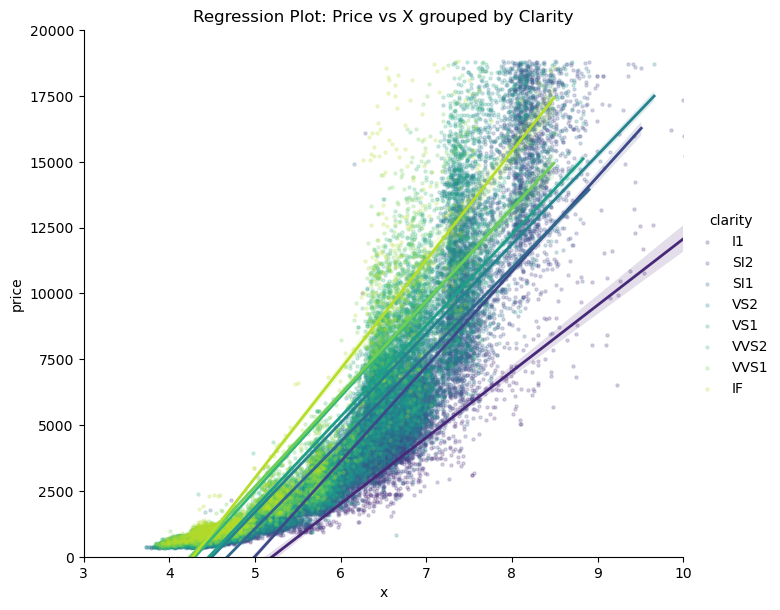

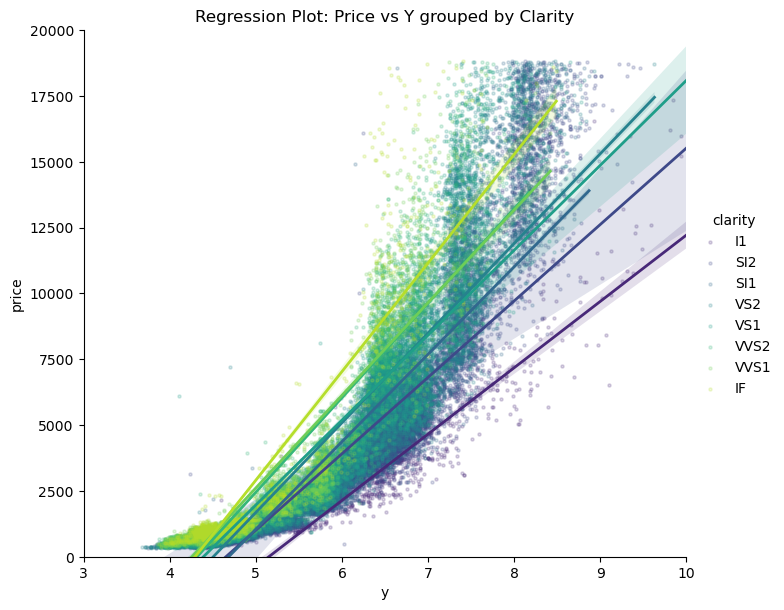

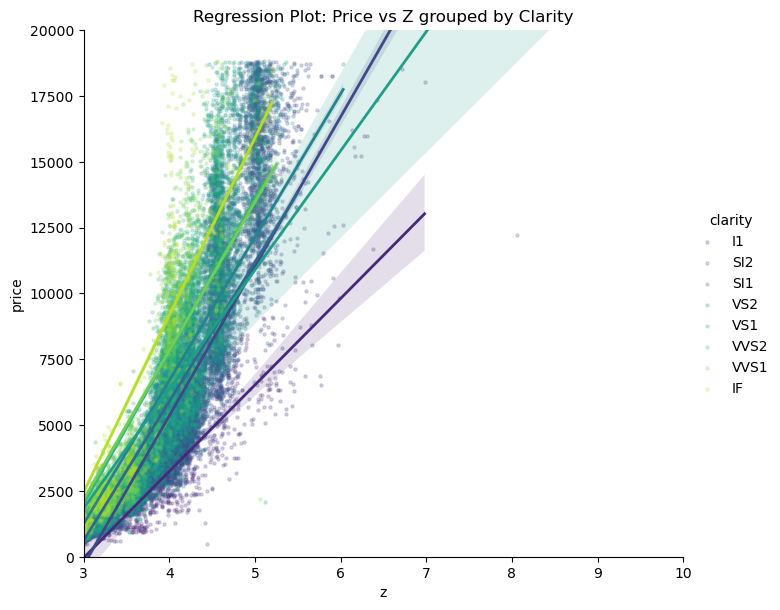

In [ ]:
target_pairs = [('price', 'x'), ('price', 'y'), ('price', 'z')]

print("Generating plots for Dimensions vs Price...")

for y_var, x_var in target_pairs:

    clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
    
    g = sns.lmplot(
        data=diamonds, 
        x=x_var, 
        y=y_var, 
        hue='clarity',
        hue_order=clarity_order,
        scatter_kws={'alpha': 0.2, 's': 5}, 
        line_kws={'linewidth': 2},
        height=6, 
        aspect=1.2,
        palette='viridis'
    )
    
    plt.title(f"Regression Plot: {y_var.capitalize()} vs {x_var.upper()} grouped by Clarity")
    plt.xlim(3, 10) 
    plt.ylim(0, 20000)
    plt.show()

actually, no. while we use regression line which is linear, we fail to catch cubic relation between size and price.

By grouping the points by clarity (how flawed the diamond is), the slopes look totally different.

The line for low-quality, heavily flawed diamonds (I1) is flat. Making a low-quality diamond bigger does not make the price much.

On the other hand, the line for flawless diamonds (IF) is so steep! For top-tier stones, even a tiny increase in size makes the price so high.